In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

qsales = pd.read_csv('AMZN_quarterly_revenue.csv')
display(qsales)

,tic,datadate,fyearq,fqtr,saleq
0,AMZN,2016-03-31,2016,1,29128
1,AMZN,2016-06-30,2016,2,30404
2,AMZN,2016-09-30,2016,3,32714
3,AMZN,2016-12-31,2016,4,43741
4,AMZN,2017-03-31,2017,1,35714
5,AMZN,2017-06-30,2017,2,37955
6,AMZN,2017-09-30,2017,3,43744
7,AMZN,2017-12-31,2017,4,60453
8,AMZN,2018-03-31,2018,1,51042
9,AMZN,2018-06-30,2018,2,52886


In [ ]:
amazon_sales = qsales.loc[qsales['tic'] == 'AMZN']
display(amazon_sales)

,tic,datadate,fyearq,fqtr,saleq
0,AMZN,2016-03-31,2016,1,29128
1,AMZN,2016-06-30,2016,2,30404
2,AMZN,2016-09-30,2016,3,32714
3,AMZN,2016-12-31,2016,4,43741
4,AMZN,2017-03-31,2017,1,35714
5,AMZN,2017-06-30,2017,2,37955
6,AMZN,2017-09-30,2017,3,43744
7,AMZN,2017-12-31,2017,4,60453
8,AMZN,2018-03-31,2018,1,51042
9,AMZN,2018-06-30,2018,2,52886


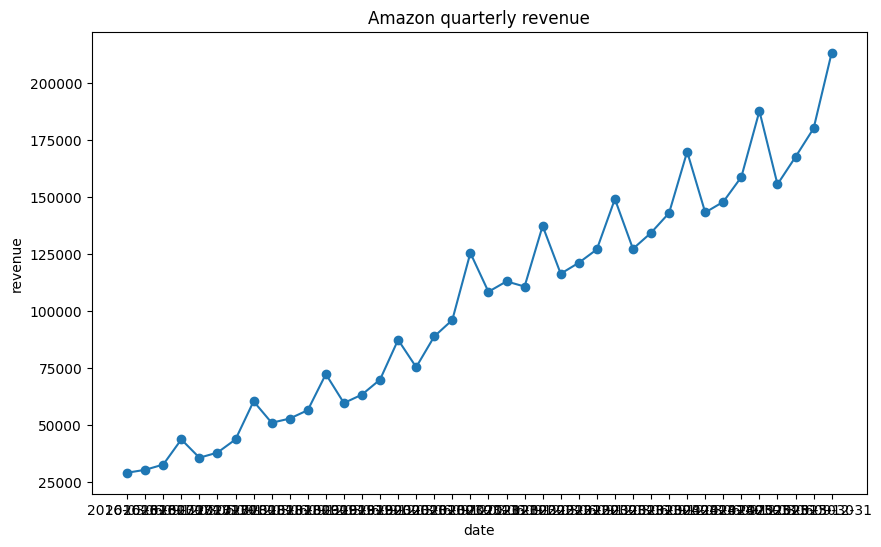

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Amazon quarterly revenue')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(amazon_sales['datadate'],amazon_sales['saleq'],marker='o')

In [ ]:
amazon_sales['time'] = range(1,len(amazon_sales)+1)
display(amazon_sales)

,tic,datadate,fyearq,fqtr,saleq,time
0,AMZN,2016-03-31,2016,1,29128,1
1,AMZN,2016-06-30,2016,2,30404,2
2,AMZN,2016-09-30,2016,3,32714,3
3,AMZN,2016-12-31,2016,4,43741,4
4,AMZN,2017-03-31,2017,1,35714,5
5,AMZN,2017-06-30,2017,2,37955,6
6,AMZN,2017-09-30,2017,3,43744,7
7,AMZN,2017-12-31,2017,4,60453,8
8,AMZN,2018-03-31,2018,1,51042,9
9,AMZN,2018-06-30,2018,2,52886,10


In [ ]:
amazon_sales['q4_dv']= np.where(amazon_sales['fqtr']==4,1,0)
amazon_sales['q4_interaction'] = amazon_sales['q4_dv'] * amazon_sales['time']

amazon_sales['q1_dv']= np.where(amazon_sales['fqtr']==1,1,0)
amazon_sales['q1_interaction'] = amazon_sales['q1_dv'] * amazon_sales['time']

display(amazon_sales)

,tic,datadate,fyearq,fqtr,saleq,time,q4_dv,q4_interaction,q1_dv,q1_interaction
0,AMZN,2016-03-31,2016,1,29128,1,0,0,1,1
1,AMZN,2016-06-30,2016,2,30404,2,0,0,0,0
2,AMZN,2016-09-30,2016,3,32714,3,0,0,0,0
3,AMZN,2016-12-31,2016,4,43741,4,1,4,0,0
4,AMZN,2017-03-31,2017,1,35714,5,0,0,1,5
5,AMZN,2017-06-30,2017,2,37955,6,0,0,0,0
6,AMZN,2017-09-30,2017,3,43744,7,0,0,0,0
7,AMZN,2017-12-31,2017,4,60453,8,1,8,0,0
8,AMZN,2018-03-31,2018,1,51042,9,0,0,1,9
9,AMZN,2018-06-30,2018,2,52886,10,0,0,0,0


In [ ]:
dt4training = amazon_sales[:int(0.75* len(amazon_sales))]
dt4testing = amazon_sales[int(0.75* len(amazon_sales)):]

display(dt4training)
display(dt4testing)

,tic,datadate,fyearq,fqtr,saleq,time,q4_dv,q4_interaction,q1_dv,q1_interaction
0,AMZN,2016-03-31,2016,1,29128,1,0,0,1,1
1,AMZN,2016-06-30,2016,2,30404,2,0,0,0,0
2,AMZN,2016-09-30,2016,3,32714,3,0,0,0,0
3,AMZN,2016-12-31,2016,4,43741,4,1,4,0,0
4,AMZN,2017-03-31,2017,1,35714,5,0,0,1,5
5,AMZN,2017-06-30,2017,2,37955,6,0,0,0,0
6,AMZN,2017-09-30,2017,3,43744,7,0,0,0,0
7,AMZN,2017-12-31,2017,4,60453,8,1,8,0,0
8,AMZN,2018-03-31,2018,1,51042,9,0,0,1,9
9,AMZN,2018-06-30,2018,2,52886,10,0,0,0,0


,tic,datadate,fyearq,fqtr,saleq,time,q4_dv,q4_interaction,q1_dv,q1_interaction
30,AMZN,2023-09-30,2023,3,143083,31,0,0,0,0
31,AMZN,2023-12-31,2023,4,169961,32,1,32,0,0
32,AMZN,2024-03-31,2024,1,143313,33,0,0,1,33
33,AMZN,2024-06-30,2024,2,147977,34,0,0,0,0
34,AMZN,2024-09-30,2024,3,158877,35,0,0,0,0
35,AMZN,2024-12-31,2024,4,187792,36,1,36,0,0
36,AMZN,2025-03-31,2025,1,155667,37,0,0,1,37
37,AMZN,2025-06-30,2025,2,167700,38,0,0,0,0
38,AMZN,2025-09-30,2025,3,180200,39,0,0,0,0
39,AMZN,2025-12-31,2025,4,213400,40,1,40,0,0


In [ ]:
y = dt4training.loc[:,'saleq']
x = dt4training.loc[:,'time']
x=sm.add_constant(x)
model1 = sm.OLS(y,x).fit()
model1.params

,0
const,18031.76
time,4124.56


In [ ]:
x_test = dt4testing.loc[:,'time']
x_test = sm.add_constant(x_test)
model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_saleq'] = model1.predict(x_test)
model1_assessment['model1_abs_pct_error'] = abs(
    (
        model1_assessment['saleq'] - model1_assessment['model1_predicted_saleq']
        )/model1_assessment['saleq']
    )

display(model1_assessment)

,tic,datadate,fyearq,fqtr,saleq,time,q4_dv,q4_interaction,q1_dv,q1_interaction,model1_predicted_saleq,model1_abs_pct_error
30,AMZN,2023-09-30,2023,3,143083,31,0,0,0,0,145893.04,0.02
31,AMZN,2023-12-31,2023,4,169961,32,1,32,0,0,150017.60,0.12
32,AMZN,2024-03-31,2024,1,143313,33,0,0,1,33,154142.16,0.08
33,AMZN,2024-06-30,2024,2,147977,34,0,0,0,0,158266.71,0.07
34,AMZN,2024-09-30,2024,3,158877,35,0,0,0,0,162391.27,0.02
35,AMZN,2024-12-31,2024,4,187792,36,1,36,0,0,166515.83,0.11
36,AMZN,2025-03-31,2025,1,155667,37,0,0,1,37,170640.39,0.10
37,AMZN,2025-06-30,2025,2,167700,38,0,0,0,0,174764.94,0.04
38,AMZN,2025-09-30,2025,3,180200,39,0,0,0,0,178889.50,0.01
39,AMZN,2025-12-31,2025,4,213400,40,1,40,0,0,183014.06,0.14


In [ ]:
y = dt4training.loc[:,'saleq']
x = dt4training.loc[:,['time','q4_dv','q4_interaction','q1_dv','q1_interaction']]
x=sm.add_constant(x)
model2 = sm.OLS(y,x).fit()
model2.params

,0
const,15846.13
time,4041.37
q4_dv,5969.01
q4_interaction,632.55
q1_dv,2455.51
q1_interaction,-233.51


In [ ]:
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.0705474184379344)

In [ ]:
x_test = dt4testing.loc[:,['time','q4_dv','q4_interaction','q1_dv','q1_interaction']]
x_test = sm.add_constant(x_test)
model2_assessment = dt4testing.copy()
model2_assessment['model2_predicted_saleq'] = model2.predict(x_test)
model2_assessment['model2_abs_pct_error'] = abs(
    (
        model2_assessment['saleq'] - model2_assessment['model2_predicted_saleq']
        )/model2_assessment['saleq']
    )

display(model2_assessment)

,tic,datadate,fyearq,fqtr,saleq,time,q4_dv,q4_interaction,q1_dv,q1_interaction,model2_predicted_saleq,model2_abs_pct_error
30,AMZN,2023-09-30,2023,3,143083,31,0,0,0,0,141128.58,0.01
31,AMZN,2023-12-31,2023,4,169961,32,1,32,0,0,171380.57,0.01
32,AMZN,2024-03-31,2024,1,143313,33,0,0,1,33,143960.93,0.00
33,AMZN,2024-06-30,2024,2,147977,34,0,0,0,0,153252.69,0.04
34,AMZN,2024-09-30,2024,3,158877,35,0,0,0,0,157294.06,0.01
35,AMZN,2024-12-31,2024,4,187792,36,1,36,0,0,190076.25,0.01
36,AMZN,2025-03-31,2025,1,155667,37,0,0,1,37,159192.36,0.02
37,AMZN,2025-06-30,2025,2,167700,38,0,0,0,0,169418.17,0.01
38,AMZN,2025-09-30,2025,3,180200,39,0,0,0,0,173459.53,0.04
39,AMZN,2025-12-31,2025,4,213400,40,1,40,0,0,208771.93,0.02


In [ ]:
model2_assessment['model2_abs_pct_error'].mean()

np.float64(0.017629691448029856)

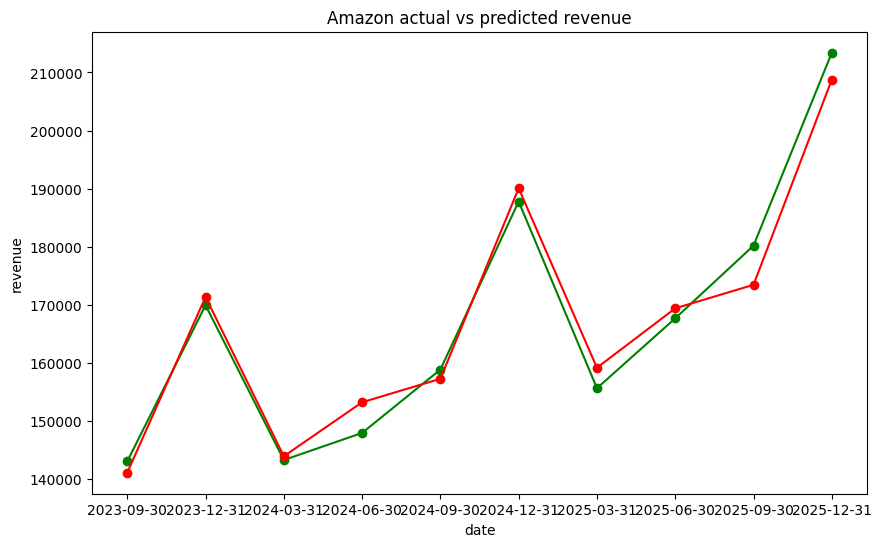

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Amazon actual vs predicted revenue')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model2_assessment['datadate'],model2_assessment['saleq'],marker='o', color = 'green')
plt.plot(model2_assessment['datadate'],model2_assessment['model2_predicted_saleq'],marker='o', color = 'red')


In [ ]:
future_quarters = pd.DataFrame({'time':[41,42,43,44],'fqtr':[1,2,3,4]})

future_quarters['q4_dv'] = np.where(future_quarters['fqtr']==4,1,0)
future_quarters['q4_interaction'] = future_quarters['time'] * future_quarters['q4_dv']

future_quarters['q1_dv'] = np.where(future_quarters['fqtr']==1,1,0)
future_quarters['q1_interaction'] = future_quarters['time'] * future_quarters['q1_dv']


In [ ]:
display(future_quarters)

x_future = future_quarters.loc[:,['time','q4_dv','q4_interaction','q1_dv','q1_interaction']]
x_future = sm.add_constant(x_future)

,time,fqtr,q4_dv,q4_interaction,q1_dv,q1_interaction
0,41,1,0,0,1,41
1,42,2,0,0,0,0
2,43,3,0,0,0,0
3,44,4,1,44,0,0


In [ ]:
model2.get_prediction(x_future).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,174423.79,6381.55,166013.95,182833.62,162879.90,185967.68
1,185583.64,4984.66,179014.68,192152.60,175303.21,195864.08
2,189625.01,5155.10,182831.44,196418.58,179199.62,200050.40
3,227467.61,8255.87,216587.72,238347.49,214017.41,240917.81


The model was created using quarterly data from Amazon(AMZN) for net sales from 2016 Q1 to 2025 Q4. Additionally, to make the model we plotted revenue over time. 2 Dummy variables were created, with one being for Q1, which represents after holidays, and one being for Q4, which represents during the holiday. Using the first 75% of the data we trained it and tested the remaining 25%. After adding the two dummy variables, I was able to cut the MAPE score from 7.1% to 1.8%. THe predicitive capability of the model is its ability to predict revenu within a 2% range on the data. Overall, the model is accurate and the patterns that it is based off of has been consistent over the last 10 years.